In [2]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr
from matplotlib.colors import to_rgba
from globalVars import *
from load_data_pickles import *
from analysis_functions import mean_and_interquartile
from plotting_variables import TINY_SIZE, SMALL_SIZE
import warnings
from itertools import product

def get_G_find(order): # global list of interfaces, data loaded from load_data_pickles
    if order == 'zero':
        return zero_order_Gs
    elif order == 'first':
        return first_order_Gs
    elif order == 'second':
        return second_order_Gs
    else:
        raise ValueError('order must be zero, first, or second')
    
def get_G_star(order): # I_init (I*), also the baseline interfaces, data loaded from load_data_pickles
    if order == 'zero':
        return G_star0 
    elif order == 'first':
        return G_star1
    elif order == 'second':
        return G_star2
    else:
        raise ValueError('order must be zero, first, or second')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Model and cost functions

In [3]:
tau = 0.321 # human delay in seconds

# Human + Machine is a delayed 2nd order system 
def Human(H, orderH = 'second'): # Human model, second order system with delay
    if orderH == 'second':
        # Params: [K, a0, a1, b0, b1, b2] with H = K * (rational)*(delay) + H_noise_avg; legacy len-5 => K=1
        H = np.asarray(H, dtype=float).ravel()
        if len(H) == 6:
            K, a0, a1, b0, b1, b2 = H[0], H[1], H[2], H[3], H[4], H[5]
        elif len(H) == 5:
            K, a0, a1, b0, b1, b2 = 1.0, H[0], H[1], H[2], H[3], H[4]
        else:
            raise ValueError('Human second-order expects 5 (legacy) or 6 [K,a0,a1,b0,b1,b2] parameters')
        H_core = np.asarray([(b0*(z(omega)**2) + b1*z(omega) + b2)*np.exp(-1j * omega * tau) / (z(omega)**2 + a0*z(omega) + a1) for omega in omegas])
        H_core = np.asarray([(b2)*np.exp(-1j * omega * tau) / (z(omega)**2 + a0*z(omega) + a1) for omega in omegas])
        H_delayed = K * H_core
        # H_not_delayed = np.asarray([(b0*(z(omega)**2) + b1*z(omega) + b2) / (z(omega)**2 + a0*z(omega) + a1) for omega in omegas])
    else:
        raise ValueError('orderH is second for now')
    return H_delayed  

def Interface(G, orderG):
    if orderG == 'zero':
        b = G[0]
        return np.asarray([b for omega in omegas])

    elif orderG == 'first':
        a,b0,b1= G[0],G[1],G[2]  # I = (b0*z+b1)/(z+a)
        return np.asarray([(b0*z(omega) + b1) / (z(omega)+a) for omega in omegas])
        
    elif orderG == 'second':
        a0, a1, b0, b1, b2 = G[0],G[1],G[2],G[3],G[4] #I = (b0*z^2+b1z+b2)/(z^2+a0z+a1)
        return np.asarray([(b0*(z(omega)**2) + b1*z(omega) + b2) / (z(omega)**2 + a0*z(omega) + a1) for omega in omegas])
    else:
        raise ValueError('orderG must be zero, first, or second')


# compute loss of human and interface
def loss_G_exp(H, G_param,orderG='first',lamH=1.5,lamG=0.5): # in the actual expriment
    D = polar2rec(amps) # D = disturbance (freq) at stim freqs
    G_ = Interface(G_param, orderG=orderG) #first(G) # I = (b0*z+b1)/(z+a) # shape = (8,N*N*N)
    Y = [D[f]/(1+soM[f]*G_[f]*H[f]) for f in range(len(soM))] # when d is output disturbnace, Y = D/(1+MIH)
    Y = np.asarray(Y) #a function of G, shape = (8,100)

    # interface input and human input
    UH = [-Y[f]*H[f] for f in range(len(soM))] #U_H = -Y*H, (freq domain)
    UG = [-Y[f]*H[f]*G_[f] for f in range(len(soM))] #U_I = -Y*H*I, (freq domain)
    UH = np.asarray(UH) #a function of G, shape = (8,100)
    UG = np.asarray(UG)  #a function of G, shape = (8,100)
    # 2-norm loss
    losses = (np.sum(abs(Y)**2,axis=0) + lamH*np.sum(abs(UH)**2,axis=0) + lamG*np.sum(abs(UG)**2,axis=0)) / np.sum(abs(D)**2)

    return losses


def fit_2nd_order_human(G, D, H_inits, H_bounds, orderH = 'second', orderG = 'first', lambda_H = 1,
                        n_freq_constrain=8, phase_max_rad=0.0, constrain_uh_time=False,
                        H_mag_max_high=None, H_mag_freq_ge_hz=0.55):
    N_reduce = N // 2
    # Stimulus freqs from globalVars: cap |H| at bins with freqs >= H_mag_freq_ge_hz (e.g. 0.55, 0.65, 0.85, 0.95 Hz)
    _H_mag_high_mask = np.asarray(freqs) >= float(H_mag_freq_ge_hz)

    def _forward_Y_UH_uH(params):
        """Freq-domain Y, UH and time-domain uH from human params (same path as trial_signals)."""
        H = Human(params, orderH=orderH)
        Y = np.asarray([D[f]/(1+soM[f]*G[f]*H[f]) for f in range(len(soM))])
        UH = np.asarray([-Y[f]*H[f] for f in range(len(soM))])
        frequency_domain_uH = np.zeros(N_reduce, dtype=complex)
        frequency_domain_uH[IX] = UH
        frequency_domain_uH[-IX] = np.conjugate(frequency_domain_uH[IX])
        uH = np.real(np.fft.ifft(frequency_domain_uH) * N_reduce)
        return H, Y, UH, uH

    def human_cost(params):
        H, Y, UH, uH = _forward_Y_UH_uH(params)
        # phase_H = np.angle(H)
        # lambda_phase = 10
        # phase_penalty = lambda_phase * np.sum(np.maximum(0, phase_H)**2)
        cost =  (np.sum(abs(Y)**2) + lambda_H*np.sum(abs(UH)**2)) / np.sum(abs(D)**2)
        # return cost + phase_penalty
        return cost #+ phase_penalty
        # return (np.sum(abs(Y)**2,axis=0) + lambda_H*np.sum(abs(UH)**2,axis=0)) / np.sum(abs(D)**2)

    # Hard inequalities (SLSQP): phase; optional uH in [-1,1]; optional |H(f)| <= H_mag_max_high for freqs >= H_mag_freq_ge_hz.
    # Option 3 — fewer/looser phase: smaller n_freq_constrain, phase_max_rad > 0, or n_freq_constrain=0 and
    # constrain_uh_time=False and no H_mag cap → L-BFGS-B (box bounds only).

    def joint_constraints(params):
        H, Y, UH, uH = _forward_Y_UH_uH(params)
        parts = []
        if n_freq_constrain > 0:
            parts.append(phase_max_rad - np.angle(H)[:n_freq_constrain])
        if constrain_uh_time:
            parts.append(uH + 1.0)
            parts.append(1.0 - uH)
        if H_mag_max_high is not None and np.any(_H_mag_high_mask):
            parts.append(float(H_mag_max_high) - np.abs(H[_H_mag_high_mask]))
        return np.concatenate(parts)

    use_slsqp = (
        n_freq_constrain > 0 or constrain_uh_time
        or (H_mag_max_high is not None and np.any(_H_mag_high_mask))
    )
    constraints = ([{'type': 'ineq', 'fun': joint_constraints}] if use_slsqp else ())
    method = 'SLSQP' if use_slsqp else 'L-BFGS-B'
    # SLSQP can propose iterates outside box bounds during line search; SciPy clips and emits RuntimeWarning (usually harmless).
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Values in x were outside bounds during a minimize step",
            category=RuntimeWarning,
        )
        kw = dict(method=method, bounds=H_bounds)
        if use_slsqp:
            kw['constraints'] = constraints
        res = minimize(human_cost, H_inits, **kw)
    return res.x, res.fun

def loss_H(G, D, H_inits, H_bounds, orderH = 'second', orderG = 'first', lambda_H = 1, return_all=False,
           n_freq_constrain=8, phase_max_rad=0.0, constrain_uh_time=False,
           H_mag_max_high=None, H_mag_freq_ge_hz=0.55):
    """Sweep over (init, bounds) pairs and return the 2nd-order fit with the lowest cost.
    inits_list: list of initial guess arrays, each of length 6 [K, a0, a1, b0, b1, b2]
    bounds_list: list of bounds, each a list of 6 (lo, hi) tuples (first is scalar gain K)
    Tries all combinations. Returns (best_params, best_cost). If return_all=True, also returns
    list of (params, cost, init_idx, bounds_idx) for every run.
    Phase / uH / high-freq |H| kwargs are passed through to fit_2nd_order_human.
    Set H_mag_max_high (e.g. 2.0) to enforce |H(f)| <= that value at all stim freqs f >= H_mag_freq_ge_hz (Hz)."""
    best_params, best_cost = None, np.inf
    all_results = []
    for (ii, inits), (ib, bounds) in product(enumerate(H_inits), enumerate(H_bounds)): # from list of inits and bounds, create all combinations
        params, cost = fit_2nd_order_human(
            G, D, inits, bounds, orderH=orderH, orderG=orderG, lambda_H=lambda_H,
            n_freq_constrain=n_freq_constrain, phase_max_rad=phase_max_rad, constrain_uh_time=constrain_uh_time,
            H_mag_max_high=H_mag_max_high, H_mag_freq_ge_hz=H_mag_freq_ge_hz)
        all_results.append((params, cost, ii, ib))
        if cost < best_cost:
            best_cost = cost
            best_params = params
    if return_all:
        return best_params, best_cost, all_results
    return best_params, best_cost

def trial_signals(H,G,D, orderH = 'second',orderG = 'first'):
    # system output
    Y = [D[f]/(1+soM[f]*G[f]*H[f]) for f in range(len(soM))] # when d is output disturbnace, Y = D/(1+MIH)
    Y = np.asarray(Y) #a function of G, shape = (8,100)

    # interface input and human input
    UH = [-Y[f]*H[f] for f in range(len(soM))] #U_H = -Y*H, (freq domain)
    UG = [-Y[f]*H[f]*G[f] for f in range(len(soM))] #U_I = -Y*H*I, (freq domain)
    UH = np.asarray(UH) #a function of G, shape = (8,100)
    UG = np.asarray(UG)  #a function of G, shape = (8,100)

    # time domain signals 
    N_reduce = N//2 #nyquist_frequency = sampling rate / 2 # N = 2400 timestamps
    frequency_domain_y = np.zeros(N_reduce, dtype=complex)
    frequency_domain_uH = np.zeros(N_reduce, dtype=complex)
    frequency_domain_uG = np.zeros(N_reduce, dtype=complex)
    D_all = np.zeros(N_reduce,dtype = complex) 

    frequency_domain_y[IX] = Y
    frequency_domain_uH[IX] = UH
    frequency_domain_uG[IX] = UG
    D_all[IX] = D
    frequency_domain_y[-IX] = np.conjugate(frequency_domain_y[IX])
    frequency_domain_uH[-IX] = np.conjugate(frequency_domain_uH[IX])
    frequency_domain_uG[-IX] = np.conjugate(frequency_domain_uG[IX])
    D_all[-IX] =  np.conjugate(D)
    # IFFT and scale by N
    y = np.real(np.fft.ifft(frequency_domain_y) * N_reduce) #time_domain_y # shape = (2400)
    uH = np.real(np.fft.ifft(frequency_domain_uH) * N_reduce) #time_domain_uH # shape = (2400)
    uG = np.real(np.fft.ifft(frequency_domain_uG) * N_reduce) #time_domain_uG # shape = (2400)
    d = np.real(np.fft.ifft(D_all) * N_reduce) # time domain disturbance signal
    # uH_clip = np.clip(uH, -1, 1) # add a constraint on the human effort uh to be within [-1,1]

    # return np.sum(abs(y)**2,axis=0), np.sum(abs(uH)**2,axis=0), np.sum(abs(uG)**2,axis=0)
    return y, uH, uG, Y, UH, UG #np.sum(abs(y)**2,axis=0), np.sum(abs(uH)**2,axis=0), np.sum(abs(uG)**2,axis=0)

In [4]:
# simulate the co-adaptation, find the final G and H after adaptation
alphaH = 0.75 # leaning rate for human adaptation 
alphaG = 0.75 # learning rate for interface adaptation

def simulate_alt(orderG='first', orderH='second', N_trial=15, 
        H_inits=[1.0, 0.1, 0.1, 0.1, 0.1, 0.1],
        H_bounds=[(1e-3, 1e2), (-10, 10), (-10, 10), (-10, 10), (-10, 10), (-10, 10)],
        HlamH=1.5,HlamG=0.5,GlamH=1.5,GlamG=0.5,
        human_n_freq_constrain=4, human_phase_max_rad=0.2, human_constrain_uh_time=False,
        human_H_mag_max_high=None, human_H_mag_freq_ge_hz=0.55, warm_start_H=True):
    # Option 3 defaults: fewer phase bins + slack angle(H)<=human_phase_max_rad. Strict: (8, 0.0); unconstrained: (0, 0.0, False).
    # High-freq |H|: set human_H_mag_max_high (e.g. 2.0) to cap |H| at stim bins with freqs >= human_H_mag_freq_ge_hz (default 0.55 Hz).
    # define all possible interface parameters
    def _human_init_candidates(h_inits):
        """Normalize H_inits to a list of length-6 vectors for loss_H."""
        hi = h_inits
        if isinstance(hi, np.ndarray):
            hi = np.asarray(hi, dtype=float)
            if hi.ndim == 2:
                return [hi[i].copy() for i in range(hi.shape[0])]
            if hi.ndim == 1 and hi.size == 6:
                return [hi.copy()]
            raise ValueError('H_inits ndarray must be shape (6,) or (n, 6)')
        if not isinstance(hi, (list, tuple)):
            raise TypeError('H_inits must be a list/tuple of init vectors or one 6-vector')
        if len(hi) == 6 and all(np.asarray(x).ndim == 0 for x in hi):
            return [np.asarray(hi, dtype=float)]
        return [np.asarray(x, dtype=float) for x in hi]

    base_H_inits = _human_init_candidates(H_inits)

    G_find = get_G_find(orderG) # list of parameters 

    Gs_param = [] # parameters
    Gs = [] # TF evaluated at 8 stim frequencies
    Hs_param = [] # parameters
    Hs = [] # TF evaluated at 8 stim frequencies
    Hs_accumulated = []

    # time domain signals
    ys = []
    uHs = []
    uGs = []

    # freq domain signals
    Ys = []
    UHs = []
    UGs = []
    Ds = []

    #starting with initial I* (given, the same as experiment)
    G_init = get_G_star(orderG)
    Gs_param.append(G_init)  
    Gs.append(Interface(G_init, orderG=orderG)) # initial G evaluated at 8 frequencies
    
    # given I*, and D, find the optimal H of this first trial
    D = polar2rec(amps) # D = disturbance (freq) at stim freqs
    params_fit, fit_error = loss_H(Gs[-1], D, H_inits=base_H_inits, H_bounds=H_bounds, orderH=orderH, orderG=orderG, lambda_H=HlamH,
        n_freq_constrain=human_n_freq_constrain, phase_max_rad=human_phase_max_rad, constrain_uh_time=human_constrain_uh_time,
        H_mag_max_high=human_H_mag_max_high, H_mag_freq_ge_hz=human_H_mag_freq_ge_hz)
    Hs_param.append(params_fit) #initial H
    Hs.append(Human(params_fit, orderH=orderH)) # initial H evaluated at 8 frequencies
    Hs_accumulated.append(Hs[-1])


    # losses of the first trial
    y, uH, uG, Y, UH, UG = trial_signals(Hs[-1],Gs[-1],D,orderH=orderH,orderG=orderG)
    ys.append(y)
    uHs.append(uH)
    uGs.append(uG)
    Ys.append(Y)
    UHs.append(UH)
    UGs.append(UG)
    Ds.append(D)

    loss_of_the_trial = (np.sum(abs(Y)**2) + GlamH*np.sum(abs(UH)**2) + GlamG*np.sum(abs(UG)**2)) / np.sum(abs(D)**2)
    #print('trial = ', 0, ', loss of this trial = ', loss_of_the_trial)

    for trial in range(N_trial-1):
        losses = loss_G_exp(Hs_accumulated[-1],G_find,orderG=orderG,lamH=GlamH,lamG=GlamG) # for the given H, compute loss for all possible Hs using grid search
        idx_min = np.argmin(losses)
        #print('optimal G index = ',idx_min, ', loss = ', losses[idx_min])
        optimal_G = G_find[:,idx_min]
        G_avg = alphaG*Gs_param[-1] + (1-alphaG)*optimal_G

        Gs_param.append(G_avg) # update G with learning rate alphaG
        Gs.append(Interface(G_avg, orderG=orderG)) # evaluate G at 8 frequencies

        # now fix G and find the optimal H for current trial
        D = polar2rec(amps) # D = disturbance (freq) at stim freqs of this trial
        if warm_start_H:
            h_inits_trial = [np.asarray(Hs_param[-1], dtype=float)] + list(base_H_inits)
        else:
            h_inits_trial = base_H_inits
        params_fit, fit_error = loss_H(Gs[-1], D, H_inits=h_inits_trial, H_bounds=H_bounds, orderH=orderH, orderG=orderG, lambda_H=HlamH,
            n_freq_constrain=human_n_freq_constrain, phase_max_rad=human_phase_max_rad, constrain_uh_time=human_constrain_uh_time,
            H_mag_max_high=human_H_mag_max_high, H_mag_freq_ge_hz=human_H_mag_freq_ge_hz)
        Hs_param.append(params_fit)
        Hs.append(Human(params_fit, orderH=orderH))
        # average previous trial's H and find the optimal G for current trial
        Hs_accumulated.append(alphaH*Hs_accumulated[-1] + (1-alphaH)*Hs[-1]) 

        y, uH, uG, Y, UH, UG = trial_signals(Hs[-1],Gs[-1],D,orderH=orderH,orderG=orderG)
        ys.append(y)
        uHs.append(uH)
        uGs.append(uG)
        Ys.append(Y)
        UHs.append(UH)
        UGs.append(UG)
        Ds.append(D)

        loss_of_the_trial = (np.sum(abs(Y)**2) + GlamH*np.sum(abs(UH)**2) + GlamG*np.sum(abs(UG)**2)) / np.sum(abs(D)**2)
        #print('trial = ', trial+1, ', loss = ', loss_of_the_trial)
    
        
    Hs_param = np.asarray(Hs_param)
    Hs = np.asarray(Hs)
    Gs_param = np.asarray(Gs_param)
    Gs = np.asarray(Gs)
    
    ys = np.asarray(ys)
    uHs = np.asarray(uHs)
    uGs = np.asarray(uGs)
    Ys = np.asarray(Ys)
    UHs = np.asarray(UHs)
    UGs = np.asarray(UGs)
    Ds = np.asarray(Ds)
    return Hs_param, Hs, Gs_param, Gs, ys, uHs, uGs, Ys, UHs, UGs, Ds

In [5]:
# Bode plot parameters
condition = 'first'
def BodeI(Gs_sim_1st, N_trial = 15):
    # plot interface
    xlim = (0.095, 1.0)
    ylimphase = (0,np.pi/2)
    yticksphase = [0.,np.pi/2]
    yticklabelsphase = [r'$0$',r'$+\pi/2$']
    final_trial_idx = 17
    xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
    increment_alpha = np.linspace(0.1,1,N_trial+1)

    fig,axs = plt.subplots(2,1,sharex=True,figsize=(1.5,1),dpi = 300)
    cond = 1
    
    ax = axs[0]
    for trial in range(N_trial):
        ax.plot(freqs,np.abs(Gs_sim_1st[trial,:]),'-o',color = 'grey',alpha=increment_alpha[trial], label = 'Isim_'+str(trial))
    ax.plot(freqs,np.abs(Gs_sim_1st[0,:]),color = 'grey',label = 'I*',linestyle='--',linewidth = 2)
    ax.plot(freqs,np.abs(Gs_sim_1st[-1,:]),color = 'black',label = 'Isim_final',linestyle='--',linewidth = 2)
    ax.set_ylabel('magnitude')
    ax.set_title(str(condition)+' order interface, 2nd-order Human')

    # overlay exp result
    for sub in range(subject_num):
        ax.plot(freqs,np.abs(Gs[sub,cond,final_trial_idx,:]),'-o',color = 'red',alpha=0.5) # last adaptive trial of the experiment

    ax = axs[1]
    for trial in range(N_trial):
        ax.plot(freqs,np.angle(Gs_sim_1st[trial,:]),'-o',color = 'grey',alpha=increment_alpha[trial], label = 'Isim_'+str(trial))
    ax.plot(freqs,np.angle(Gs_sim_1st[0,:]),color = 'grey',label = 'I*',linestyle='--',linewidth = 2)
    ax.plot(freqs,np.angle(Gs_sim_1st[-1,:]),color = 'black',label = 'Isim_final',linestyle='--',linewidth = 2)

    # overlay exp result
    for sub in range(subject_num):
        ax.plot(freqs,np.angle(Gs[sub,cond,final_trial_idx,:]),'-o',color = 'red',alpha=0.5) # last adaptive trial of the experiment

    ax.set_ylabel('Phase') 
    ax.set_xlabel('frequency')
    ax.grid('on',zorder=-1)
    ax.set_ylim(ylimphase)
    ax.set_yticks(yticksphase)
    ax.set_yticklabels(yticklabelsphase)
    ax.set_xscale("log")
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks,rotation=90) 
    plt.show()

def BodeH(Hs_sim_1st, N_trial = 15):
    # plot interface
    xlim = (0.095, 1.0)
    ylimphase = (-np.pi,np.pi)
    yticksphase = [-np.pi,0.,np.pi]
    yticklabelsphase = [r'$-\pi$', r'$0$',r'$+\pi$']
    final_trial_idx = 17
    xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
    increment_alpha = np.linspace(0.1,1,N_trial+1)

    fig,axs = plt.subplots(2,1,sharex=True,figsize=(1.5,1),dpi = 300)
    cond = 1
    ax = axs[0]
    for trial in range(N_trial):
        ax.plot(freqs,np.abs(Hs_sim_1st[trial,:]),'-o',color = 'grey',alpha=increment_alpha[trial], label = 'Hsim_'+str(trial))
    ax.plot(freqs,np.abs(Hs_sim_1st[0,:]),color = 'grey',label = 'Hsim_init',linestyle='--',linewidth = 2)
    ax.set_ylabel('H magnitude')
    ax.set_title(str(condition)+' order interface, 2nd-order Human')

    # overlay exp result
    for sub in range(subject_num):
        ax.plot(freqs,np.abs(Hs[sub,cond,final_trial_idx,IX]),'-o',color = 'red',alpha=0.5) # last adaptive trial of the experiment
    ax.plot(freqs,np.abs(Hs_sim_1st[-1,:]),color = 'black',label = 'Hsim_final',linestyle='--',linewidth = 2)

    ax = axs[1]
    for trial in range(N_trial):
        ax.plot(freqs,np.angle(Hs_sim_1st[trial,:]),'-o',color = 'grey',alpha=increment_alpha[trial], label = 'Hsim_'+str(trial))
    ax.plot(freqs,np.angle(Hs_sim_1st[0,:]),color = 'grey',label = 'Hsim_init',linestyle='--',linewidth = 2)

    # overlay exp result
    for sub in range(subject_num):
        ax.plot(freqs,np.angle(Hs[sub,cond,final_trial_idx,IX]),'-o',color = 'red',alpha=0.5) # last adaptive trial of the experiment

    ax.plot(freqs,np.angle(Hs_sim_1st[-1,:]),color = 'black',label = 'Hsim_final',linestyle='--',linewidth = 2)
    ax.set_ylabel('H Phase') 
    ax.set_xlabel('frequency')
    ax.grid('on',zorder=-1)
    ax.set_ylim(ylimphase)
    ax.set_yticks(yticksphase)
    ax.set_yticklabels(yticklabelsphase)
    ax.set_xscale("log")
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks,rotation=90) 
    plt.show()

In [8]:
# parameter inits

bound_max = np.array([ 2.69036221,  9.03433397,  5.11106113, 10.        ,  4.9025499 ])
bound_min = np.array([-10.        ,  -3.07998431,  -6.69702089, -10.        ,-4.7335859 ])
K_bound = (1e-3, 1e2)  # explicit gain on rational×delay (before H_noise_avg)
H_bounds_shape = list(zip(bound_min, bound_max))  # a0..b2 from empirical spread
H_bounds = [K_bound] + H_bounds_shape
print(H_bounds)

# Use sweep to get the best 1st-order fit over multiple inits and bounds
H_inits_list = [[1.0, 0.1, 0.1, 0.1, 0.1, 0.1], 
            [2.0, 0.1, 0.1, 0.1, 0.1, 0.1],
            [0.5, 0.1, 0.1, 0.1, 0.1, 0.1],
            [1.0, 0.2, 0.2, 0.2, 0.2, 0.2],
            [1.0, 0.5, 0.5, 0.5, 0.5, 0.5], 
            [1.0, -0.5, -0.5, -0.5, -0.5, -0.5],
            [1.0, -0.1, -0.1, -0.1, -0.1, -0.1],
            [1.0, 0, 0, 0, 0, 0],
            [1.0, 1, 1, 1, 1, 1],
            [1.0, 1, -1, 1, -1, 1],
            [1.0, -1, 1, -1, 1, -1],
            [1.0, -1.0, 0.35, 0.5, 0.0, 0.0],
            [1.0, 0.2, 0.05, 2.0, 1.5, 1.0],
            [1.0, -0.5, 0.2, -0.8, 0.6, 0.1],  # mixed signs
            [1.0, 0.3, -0.15, 0.4, -0.5, 0.2],
]
H_bounds_list = [
    [(1e-3, 1e2), (-5, 5), (-5, 5), (-5, 5), (-5, 5), (-5, 5)],
    [(1e-3, 1e2), (-10, 10), (-10, 10), (-10, 10), (-10, 10), (-10, 10)],
    [(1e-3, 1e2), (-20, 20), (-20, 20), (-20, 20), (-20, 20), (-20, 20)],
    H_bounds]

[(0.001, 100.0), (np.float64(-10.0), np.float64(2.69036221)), (np.float64(-3.07998431), np.float64(9.03433397)), (np.float64(-6.69702089), np.float64(5.11106113)), (np.float64(-10.0), np.float64(10.0)), (np.float64(-4.7335859), np.float64(4.9025499))]


# Example Simulation

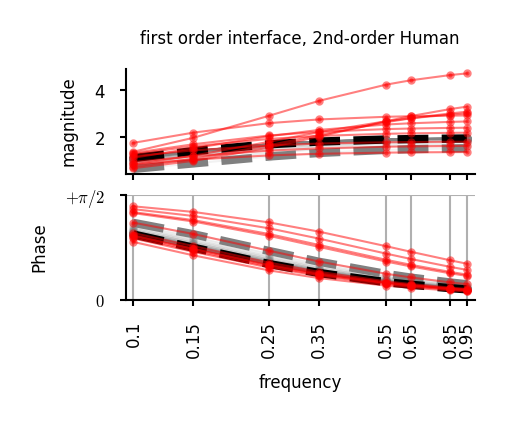

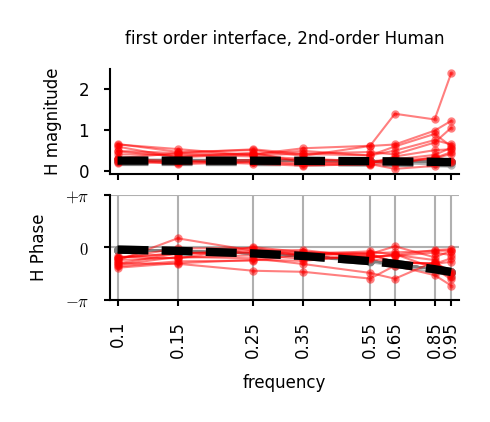

In [10]:
# no constraint in human cost
N_trial = 15
orderH = 'second' #2nd order human
orderG = 'first' #1st order interface

(HlamH, GlamH, GlamG) = (2.04, 5.5, 1.32) # best, after sweeping lambda

Hs_sim_parameters_1st, Hs_sim_1st, Gs_sim_parameters_1st, Gs_sim_1st, time_domain_y, time_domain_uH, time_domain_uG, freq_domain_Y, freq_domain_UH, freq_domain_UG, freq_domain_D = \
      simulate_alt(orderG = orderG, orderH = orderH, N_trial = N_trial, H_inits = H_inits_list, H_bounds = H_bounds_list,
      human_n_freq_constrain=8, human_phase_max_rad=-0.15, human_constrain_uh_time=False,
      HlamH=HlamH,GlamH=GlamH,GlamG=GlamG,
      human_H_mag_max_high=2.5, human_H_mag_freq_ge_hz=0.55)  # e.g. 2.0 to enforce |H|<=2 at freqs >= 0.55 Hz (tune from empirical |H|)

BodeI(Gs_sim_1st, N_trial = N_trial)
BodeH(Hs_sim_1st, N_trial = N_trial)

# Grid search over lambdas

## NOTE: Running this cell takes a while! Load pickle file simulation_results.pkl to skip this.

In [ ]:
"""SKIP THIS CELL and load pickle"""

N_trial = 15
orderH = 'second' # second order human model
orderG = 'first' #1st order interface
# Grid search (HlamH, GlamH, GlamG): sim |H| averaged over last 3 trials vs empirical median |H| (last 3 trials, same definition as H_last_3_trials).

cond_emp = 1  # first-order-interface column in Hs
H_last_3_trials_mag = np.mean(np.abs(Hs[:, cond_emp, 15:18, :])[:, :, IX], axis=1)
H_emp_median_mag = np.median(H_last_3_trials_mag, axis=0)

I_last_3_trials_mag = np.mean(abs(Gs[:,cond_emp,15:18,:]),axis = 1) # last 3 adaptive trials 
G_emp_median_mag = np.median(I_last_3_trials_mag, axis=0)

# Lambda grids: full 21^3 ~ 9k simulate_alt calls is very slow. Use coarse-to-fine by default.
#   GRID_MODE = "coarse_fine" — stage 1 sparse axis, stage 2 local box around best (~hundreds of sims)
#   GRID_MODE = "full"       — exhaustive product on lam_grid (slow)
GRID_MODE = "coarse_fine"
N_COARSE_AXIS = 6          # linear spacings in [0.5, 10] plus 1e-4  -> (N_COARSE_AXIS+1)^3 stage-1 evals
REFINE_FRAC = 0.45       # stage 2: each axis spans [x*(1-f), x*(1+f)] clipped to [1e-4, 10]
N_REFINE_AXIS = 4        # points per axis in stage 2 (N_REFINE_AXIS^3 evals, many may duplicate)

# Full-resolution axis (only used when GRID_MODE == "full")
lam_grid = np.linspace(0.5, 10, 20)
lam_grid = np.insert(lam_grid, 0, 1e-4)

_sim_kw = dict(
    orderG=orderG, orderH=orderH, N_trial=N_trial,
    H_inits=H_inits_list, H_bounds=H_bounds_list,
    human_n_freq_constrain=8, human_phase_max_rad=-0.15, human_constrain_uh_time=False,
    # human_H_mag_max_high=None, human_H_mag_freq_ge_hz=0.55,
    human_H_mag_max_high=2.5, human_H_mag_freq_ge_hz=0.55,
)

def _lam_error(HlamH, GlamH, GlamG):
    _out = simulate_alt(**_sim_kw, HlamH=HlamH, GlamH=GlamH, GlamG=GlamG)
    Hs_s, Gs_s = _out[1], _out[3]
    H_sim_mag = Hs_s[-1, :]
    G_sim_mag = Gs_s[-1, :]
    return 5 * np.linalg.norm(H_sim_mag - H_emp_median_mag) + np.linalg.norm(G_sim_mag - G_emp_median_mag)

def _local_axis(x, frac=REFINE_FRAC, n=N_REFINE_AXIS, lo_b=1e-4, hi_b=10.0):
    x = float(np.clip(x, lo_b, hi_b))
    lo = max(lo_b, x * (1.0 - frac))
    hi = min(hi_b, x * (1.0 + frac))
    if hi <= lo:
        hi = min(hi_b, lo + 1e-3)
    return np.linspace(lo, hi, n)

best_err = np.inf
best_triple = None
n_eval = 0

if GRID_MODE == "full":
    HlamH_grid = GlamH_grid = GlamG_grid = lam_grid
    triples = product(HlamH_grid, GlamH_grid, GlamG_grid)
else:
    lam_coarse = np.unique(np.concatenate([[1e-4], np.linspace(0.5, 10, N_COARSE_AXIS)]))
    triples_stage1 = list(product(lam_coarse, lam_coarse, lam_coarse))
    triples = iter(triples_stage1)

for HlamH, GlamH, GlamG in triples:
    err = _lam_error(HlamH, GlamH, GlamG)
    n_eval += 1
    if err < best_err:
        best_err = err
        best_triple = (HlamH, GlamH, GlamG)

if GRID_MODE == "coarse_fine" and best_triple is not None:
    h0, gh0, gg0 = best_triple
    H2, GH2, GG2 = _local_axis(h0), _local_axis(gh0), _local_axis(gg0)
    seen = {tuple(np.round(t, 12)) for t in triples_stage1}
    for HlamH, GlamH, GlamG in product(H2, GH2, GG2):
        key = tuple(np.round((HlamH, GlamH, GlamG), 12))
        if key in seen:
            continue
        seen.add(key)
        err = _lam_error(HlamH, GlamH, GlamG)
        n_eval += 1
        if err < best_err:
            best_err = err
            best_triple = (HlamH, GlamH, GlamG)

print(f"grid search: mode={GRID_MODE}, simulate_alt evaluations ≈ {n_eval}")

HlamH, GlamH, GlamG = best_triple
print(f"Best (HlamH, GlamH, GlamG) = ({HlamH}, {GlamH}, {GlamG}); L2 error vs median |H| (empirical last-3): {best_err:.4g}")

Hs_sim_parameters_1st, Hs_sim_1st, Gs_sim_parameters_1st, Gs_sim_1st, time_domain_y, time_domain_uH, time_domain_uG, freq_domain_Y, freq_domain_UH, freq_domain_UG, freq_domain_D = \
      simulate_alt(**_sim_kw, HlamH=HlamH, GlamH=GlamH, GlamG=GlamG)

# # Save the simulated data to the pickle file
# save_data = [Hs_sim_parameters_1st, Hs_sim_1st, Gs_sim_parameters_1st, Gs_sim_1st, time_domain_y, time_domain_uH, time_domain_uG, freq_domain_Y, freq_domain_UH, freq_domain_UG, freq_domain_D, best_triple]
# with open('simulated_results_sweep_lambda.pkl', 'wb') as f:
#     pickle.dump(save_data, f)


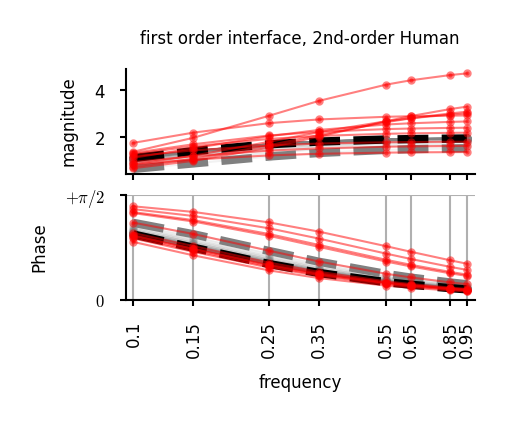

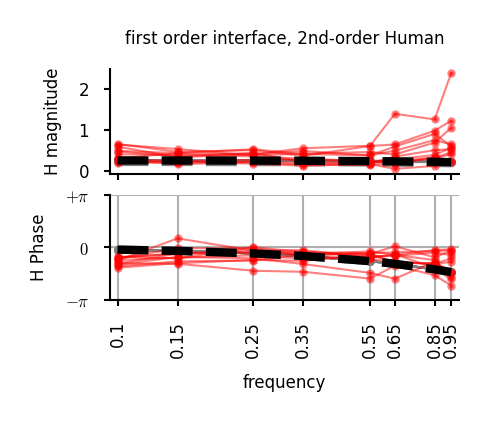

In [11]:
# load pickle file
with open('simulation_results.pkl', 'rb') as f:
    Hs_sim_parameters_1st, Hs_sim_1st, Gs_sim_parameters_1st, Gs_sim_1st, time_domain_y, time_domain_uH, time_domain_uG, freq_domain_Y, freq_domain_UH, freq_domain_UG, freq_domain_D, best_triple = pickle.load(f)

BodeI(Gs_sim_1st)
BodeH(Hs_sim_1st)

# losses

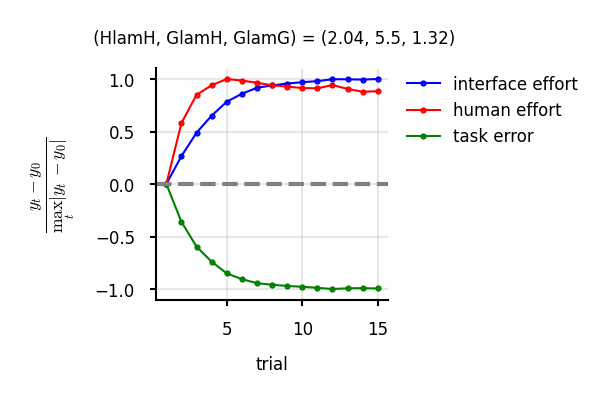

In [12]:
interface_effort_1st = np.sum(abs(freq_domain_UG) ** 2, axis=1)
human_effort_1st = np.sum(abs(freq_domain_UH) ** 2, axis=1)
task_error_1st = np.sum(abs(freq_domain_Y) ** 2, axis=1)

def diff_by_trial0(y):
    y = np.asarray(y, dtype=float)
    y0 = float(y[0])
    return y - y0 if y0 != 0 else y

def diff_by_trial0_norm_by_max(y):
    """(y - y0) / max_t |y_t - y0|: deviation from trial 0 scaled by largest absolute change."""
    y = np.asarray(y, dtype=float)
    y0 = float(y[0])
    d = y - y0
    m = float(np.max(np.abs(d)))
    return d / m if m > 0 else d


interface_effort_1st_n = diff_by_trial0_norm_by_max(interface_effort_1st)
human_effort_1st_n = diff_by_trial0_norm_by_max(human_effort_1st)
task_error_1st_n = diff_by_trial0_norm_by_max(task_error_1st)

# plot loss (single axes: each series ÷ its value at trial 0)
fig, ax = plt.subplots(figsize=(1, 1), dpi=300)
ax.plot(range(1,N_trial+1), interface_effort_1st_n, '-',marker = '.', color='blue', label='interface effort')
ax.plot(range(1,N_trial+1), human_effort_1st_n, '-',marker = '.', color='red', label='human effort')
ax.plot(range(1,N_trial+1), task_error_1st_n, '-', marker = '.', color='green', label='task error')
ax.set_xlabel('trial')
# add a horizontal line at y = 0
ax.axhline(0, color='grey', linewidth=1, linestyle='--')
ax.set_ylabel('diff to initial')
ax.set_ylabel(r'$\frac{y_t - y_0}{\max_t |y_t - y_0|}$',fontsize=SMALL_SIZE)
ax.set_title(' (HlamH, GlamH, GlamG) = (2.04, 5.5, 1.32)')
ax.grid(True, alpha=0.3)
ax.set_xticks([5,10,15])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,frameon=False)
plt.show()

# varing penalty terms

In [13]:
lam_grid = np.linspace(0.05, 8, 50)
print(lam_grid)


_sim_kw_pen = dict(
    orderG=orderG, orderH=orderH, N_trial=N_trial,
    H_inits=H_inits_list, H_bounds=H_bounds_list,
    human_n_freq_constrain=8, human_phase_max_rad=-0.15, human_constrain_uh_time=False,
    human_H_mag_max_high=None, human_H_mag_freq_ge_hz=0.55, # ran this and save in pickle simulated_results_sweep_3_lambdas_0511
    # human_H_mag_max_high=2.5, human_H_mag_freq_ge_hz=0.55, # ran this and save in pickle simulated_results_sweep_3_lambda
)
try:
    _h0, _gh0, _gg0 = best_triple
except NameError:
    try:
        _h0, _gh0, _gg0 = float(HlamH), float(GlamH), float(GlamG)
    except NameError:
        _h0, _gh0, _gg0 = 1.5, 1.5, 1.5

_lg = np.asarray(lam_grid, dtype=float)
penalty_sweep_fixed = (float(_h0), float(_gh0), float(_gg0))

[0.05       0.2122449  0.3744898  0.53673469 0.69897959 0.86122449
 1.02346939 1.18571429 1.34795918 1.51020408 1.67244898 1.83469388
 1.99693878 2.15918367 2.32142857 2.48367347 2.64591837 2.80816327
 2.97040816 3.13265306 3.29489796 3.45714286 3.61938776 3.78163265
 3.94387755 4.10612245 4.26836735 4.43061224 4.59285714 4.75510204
 4.91734694 5.07959184 5.24183673 5.40408163 5.56632653 5.72857143
 5.89081633 6.05306122 6.21530612 6.37755102 6.53979592 6.70204082
 6.86428571 7.02653061 7.18877551 7.35102041 7.51326531 7.6755102
 7.8377551  8.        ]


## NOTE: Running this cell takes a while! Load pickle file 'simulated_results_sweep_penalty.pkl' to skip this.

In [ ]:
"""SKIP THIS CELL and load pickle"""

# 3 sweeps: vary one λ along lam_grid; store full freq-domain co-adaptation (all trials × 8 stim bins).
# penalty_sweep_uI, penalty_sweep_uH, penalty_sweep_Y, penalty_sweep_D: shape (3, len(lam_grid), N_trial, 8), complex.
# interface_loss_sweeps, human_loss_sweeps: shape (3, len(lam_grid), N_trial), float (same formulas as interface_loss_1st / human_loss_1st).
#   axis 0: row 0 = vary λ_HH, row 1 = vary λ_GH, row 2 = vary λ_GG
#   uI = U_G (interface), uH = U_H (human), Y = task; D = disturbance (same as simulate_alt).

def _freq_domain_trials(HlamH, GlamH, GlamG):
    """UG, UH, Y, D each (N_trial, n_stim) complex at stim frequencies."""
    out = simulate_alt(**_sim_kw_pen, HlamH=HlamH, GlamH=GlamH, GlamG=GlamG)
    Ys, UHs, UGs, Ds = out[7], out[8], out[9], out[10]
    den = np.maximum(np.sum(abs(Ds) ** 2, axis=1), 1e-30)
    interface_loss = (
        np.sum(abs(Ys) ** 2, axis=1)
        + GlamH * np.sum(abs(UHs) ** 2, axis=1)
        + GlamG * np.sum(abs(UGs) ** 2, axis=1)
    ) / den
    human_loss = (np.sum(abs(Ys) ** 2, axis=1) + HlamH * np.sum(abs(UHs) ** 2, axis=1)) / den
    return np.asarray(UGs), np.asarray(UHs), np.asarray(Ys), np.asarray(Ds), interface_loss, human_loss


def _sweep_vary_hlam(lam_vec, h0, gh0, gg0):
    ui, uh, yy, dd, il, hl = [], [], [], [], [], []
    for lam in lam_vec:
        ug, uh_ar, y_ar, d_ar, intf, hum = _freq_domain_trials(lam, gh0, gg0)
        ui.append(ug)
        uh.append(uh_ar)
        yy.append(y_ar)
        dd.append(d_ar)
        il.append(intf)
        hl.append(hum)
    return (
        np.stack(ui, axis=0),
        np.stack(uh, axis=0),
        np.stack(yy, axis=0),
        np.stack(dd, axis=0),
        np.stack(il, axis=0),
        np.stack(hl, axis=0),
    )


def _sweep_vary_glamh(lam_vec, h0, gh0, gg0):
    ui, uh, yy, dd, il, hl = [], [], [], [], [], []
    for lam in lam_vec:
        ug, uh_ar, y_ar, d_ar, intf, hum = _freq_domain_trials(h0, lam, gg0)
        ui.append(ug)
        uh.append(uh_ar)
        yy.append(y_ar)
        dd.append(d_ar)
        il.append(intf)
        hl.append(hum)
    return (
        np.stack(ui, axis=0),
        np.stack(uh, axis=0),
        np.stack(yy, axis=0),
        np.stack(dd, axis=0),
        np.stack(il, axis=0),
        np.stack(hl, axis=0),
    )


def _sweep_vary_glamg(lam_vec, h0, gh0, gg0):
    ui, uh, yy, dd, il, hl = [], [], [], [], [], []
    for lam in lam_vec:
        ug, uh_ar, y_ar, d_ar, intf, hum = _freq_domain_trials(h0, gh0, lam)
        ui.append(ug)
        uh.append(uh_ar)
        yy.append(y_ar)
        dd.append(d_ar)
        il.append(intf)
        hl.append(hum)
    return (
        np.stack(ui, axis=0),
        np.stack(uh, axis=0),
        np.stack(yy, axis=0),
        np.stack(dd, axis=0),
        np.stack(il, axis=0),
        np.stack(hl, axis=0),
    )

# run 150 simulations
ui1, uh1, yy1, dd1, intf1, hum1 = _sweep_vary_hlam(_lg, _h0, _gh0, _gg0)
ui2, uh2, yy2, dd2, intf2, hum2 = _sweep_vary_glamh(_lg, _h0, _gh0, _gg0)
ui3, uh3, yy3, dd3, intf3, hum3 = _sweep_vary_glamg(_lg, _h0, _gh0, _gg0)

penalty_sweep_uI = np.stack([ui1, ui2, ui3], axis=0)  # (3, len(lam_grid), N_trial, 8)
penalty_sweep_uH = np.stack([uh1, uh2, uh3], axis=0)
penalty_sweep_Y = np.stack([yy1, yy2, yy3], axis=0)
penalty_sweep_D = np.stack([dd1, dd2, dd3], axis=0)

interface_loss_sweeps = np.stack([intf1, intf2, intf3], axis=0).astype(float)
human_loss_sweeps = np.stack([hum1, hum2, hum3], axis=0).astype(float)

print(
    f"penalty sweeps: uI/uH/Y/D {penalty_sweep_uI.shape}; "
    f"interface_loss_sweeps / human_loss_sweeps {interface_loss_sweeps.shape} "
    f"({len(_lg) * 3} simulate_alt calls)"
)

In [14]:
# load the pickle file 
with open('simulated_results_sweep_penalty.pkl', 'rb') as f:
    penalty_sweep_uI, penalty_sweep_uH, penalty_sweep_Y, penalty_sweep_D, interface_loss_sweeps, human_loss_sweeps = pickle.load(f)


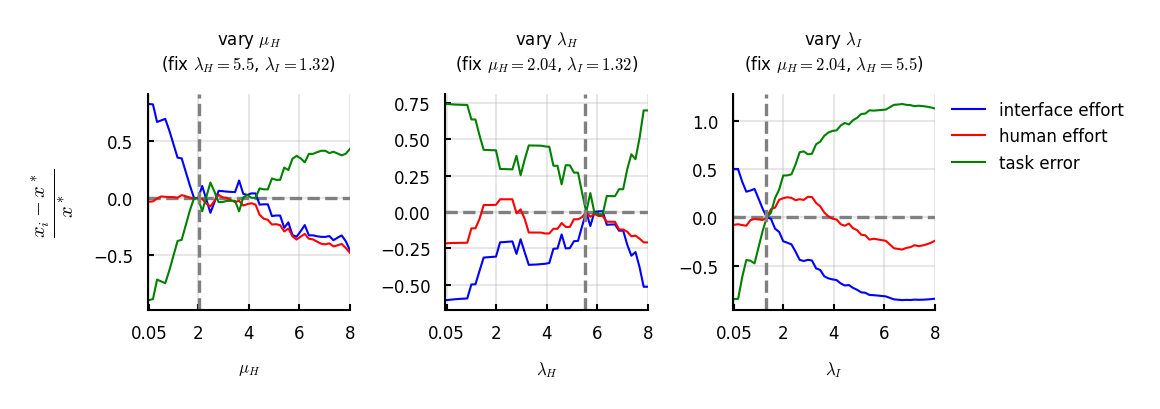

In [15]:
def _final_trial_energy_sum(x_lam_trial_freq):
    """x shape (len_lam, N_trial, n_stim) → ∑_freq |·|² on last trial vs λ (len_lam,)."""
    # return np.sum(np.abs(x_lam_trial_freq[:, -3:, :]) ** 2, axis=(1,2))
    return np.linalg.norm(x_lam_trial_freq[:, -3:, :], axis=(1,2))


def _iface_loss_last3_mean(row):
    """Mean interface loss over last 3 trials vs λ (same trial window as energy sum)."""
    return np.mean(interface_loss_sweeps[row, :, -3:], axis=1)

_h0p, _gh0p, _gg0p = penalty_sweep_fixed
_nt = int(N_trial)
titles = (
    rf"vary $\mu_{{H}}$"+"\n"+rf"(fix $\lambda_{{H}}={_gh0p:.3g}$, $\lambda_{{I}}={_gg0p:.3g}$)",
    rf"vary $\lambda_{{H}}$"+"\n"+rf"(fix $\mu_{{H}}={_h0p:.3g}$, $\lambda_{{I}}={_gg0p:.3g}$)",
    rf"vary $\lambda_{{I}}$"+"\n"+rf"(fix $\mu_{{H}}={_h0p:.3g}$, $\lambda_{{H}}={_gh0p:.3g}$)",
)
xlabels = (r"$\mu_{H}$", r"$\lambda_{H}$", r"$\lambda_{I}$")
optimal_penalties = (2.04, 5.5, 1.32)
legends = (r"$\|U_I\|^2$ (interface)", r"$\|U_H\|^2$ (human)", r"$\|Y\|^2$ (task)")
legends = ['interface effort', 'human effort', 'task error']

MA_WINDOW = 10


def _moving_average_same(y, window=MA_WINDOW):
    """Centered moving average with shorter edge windows, preserving array length."""
    y = np.asarray(y, dtype=float)
    if window <= 1 or y.size == 0:
        return y
    half = window // 2
    return np.array([
        np.mean(y[max(0, i - half) : min(y.size, i + half + 1)])
        for i in range(y.size)
    ])


def _normalize_to_idx(y, idx):
    """Normalize by the value at the λ grid point closest to the chosen optimum."""
    y = np.asarray(y, dtype=float)
    d = y - y[idx]
    return d / y[idx]


fig, axs = plt.subplots(1, 3, figsize=(3.75, 1.25), dpi=300, constrained_layout=True)
for row, ax, title, xlab in zip(range(3), axs, titles, xlabels):
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    opt_idx = int(np.argmin(np.abs(_lg - optimal_penalties[row])))
    eI = _normalize_to_idx(_moving_average_same(_final_trial_energy_sum(penalty_sweep_uI[row])), opt_idx)
    eH = _normalize_to_idx(_moving_average_same(_final_trial_energy_sum(penalty_sweep_uH[row])), opt_idx)
    eY = _normalize_to_idx(_moving_average_same(_final_trial_energy_sum(penalty_sweep_Y[row])), opt_idx)
    ci = _normalize_to_idx(_moving_average_same(_iface_loss_last3_mean(row)), opt_idx)

    ax.plot(_lg, eI, "-",  color="blue", label=legends[0])
    ax.plot(_lg, eH, "-",  color="red", label=legends[1])
    ax.plot(_lg, eY, "-", color="green", label=legends[2])
    ax.set_xlabel(xlab)
    ax.set_title(title, fontsize=TINY_SIZE)
    # ax.set_xscale("symlog", linthresh=1e-3)
    ax.grid(True, alpha=0.3)
    
    ax.set_xticks([0.05,2,4,6,8])
    ax.set_xticklabels([0.05,2,4,6,8])
    ax.set_xlim(0,8)
    ax.tick_params(direction="in")

    # ax_r = ax.twinx()
    # ax_r.plot(_lg, ci, "-", marker=".", color="purple", label=r"$c_I$")
    # ax_r.set_ylabel(r"normalized mean $c_I$ (last 3 trials)", color="purple", fontsize=7)
    # ax_r.tick_params(axis="y", labelcolor="purple", labelsize=7)

h1, l1 = ax.get_legend_handles_labels()
# h2, l2 = ax_r.get_legend_handles_labels()
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False)
# ax.legend(h1 + h2, l1 + l2, loc="best", frameon=False)

# add vertical lines at Best (HlamH, GlamH, GlamG) = (2.04, 5.5, 1.32)
axs[0].axvline(2.04, color="grey", linewidth=0.8, linestyle="--")
axs[1].axvline(5.5, color="grey", linewidth=0.8, linestyle="--")
axs[2].axvline(1.32, color="grey", linewidth=0.8, linestyle="--")

axs[0].set_ylabel(r'$\frac{x_i - x^*}{x^*}$',fontsize=SMALL_SIZE+1)
# axs[0].set_ylabel(r"normalized last 3 trials $\sum|\cdot|^2$")
# plt.suptitle(
#     f"Energy vs λ moving average normalized to optimum (window={MA_WINDOW}, trial {_nt}), N_trial={_nt}",
#     y=1.02,
#     fontsize=9,
# )
plt.show()